# Arxiv Dataset

## Introduction

This project explores the arXiv dataset with the goal of understanding patterns in scientific research through the analysis of paper abstracts. The dataset contains metadata for a large collection of research papers, including titles, authors, categories, and abstracts. For this analysis, we focus primarily on the abstract text, as it provides a concise summary of each paper’s content and is well-suited for natural language processing (NLP) techniques.

To enable meaningful analysis, the abstract text was preprocessed using standard NLP techniques, including tokenization, stopword removal, and lemmatization. This preprocessing step transforms raw text into a structured format that can be used for both exploratory analysis and modeling.

### Project Objectives

The primary goal of this project is to investigate whether meaningful structure and patterns can be extracted from research abstracts. Specifically, this portion of the analysis focuses on the following questions:

**What are the most common terms across all abstracts?**
* This helps identify general language patterns and commonly used terminology in scientific writing.

**How does vocabulary differ across research domains?**
* By comparing term usage across arXiv categories, we can determine whether different fields exhibit distinct linguistic signatures.

**Do similar papers cluster together naturally based on their abstract content?**
* Using unsupervised learning techniques such as KMeans clustering, we evaluate whether papers group into meaningful clusters without using predefined labels.

### Methodology Overview

The analysis follows a structured pipeline:

**Data Preparation**
* Load and sample the arXiv dataset
* Extract relevant fields (e.g., id, abstract, categories)
* Preserve identifiers to maintain linkage with metadata

**Text Preprocessing**
* Lowercasing and cleaning text
* Tokenization
* Stopword removal (including domain-specific stopwords)
* Lemmatization using NLTK

**Exploratory Data Analysis (EDA)**
* Word frequency analysis
* Domain-specific vocabulary comparison using TF-IDF
* Visualization of key term distributions

**Unsupervised Learning**
* Convert text into numerical features using TF-IDF
* Apply clustering algorithms (KMeans)
* Evaluate clustering performance using multiple metrics
* Visualize clusters using dimensionality reduction techniques

Below is a Data Dictionary to aid us in the understanding of the data.

## Data Dictionary

| Column Name      | Data Type     | Description                                                                                                                                            |
| ---------------- | ------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------ |
| `id`             | string        | Unique identifier assigned to each paper on arXiv (e.g., `0704.0001`). Can be used to construct URLs to the paper.                                     |
| `submitter`      | string        | Name of the individual who submitted the paper to arXiv (not necessarily the first author).                                                            |
| `authors`        | string        | Raw, comma-separated list of authors as a single text field.                                                                                           |
| `authors_parsed` | list of lists | Structured representation of authors in the format `[Last Name, First Name(s), Suffix]`.                                                               |
| `title`          | string        | Title of the research paper.                                                                                                                           |
| `abstract`       | string        | Full abstract of the paper.                                                                                                                            |
| `categories`     | string        | Space-separated list of subject categories assigned by arXiv (e.g., `cs.AI`, `math.CO`). The first category is considered the primary classification.  |
| `comments`       | string / null | Optional author-provided comments (e.g., number of pages, figures, publication notes).                                                                 |
| `journal-ref`    | string / null | Reference to the journal where the paper was published, if applicable.                                                                                 |
| `doi`            | string / null | Digital Object Identifier linking to the published version of the paper.                                                                               |
| `report-no`      | string / null | Institutional or technical report number associated with the paper.                                                                                    |
| `license`        | string / null | URL specifying the licensing terms under which the paper is distributed.                                                                               |
| `versions`       | list of dicts | List of version records, each containing version number and submission date (e.g., `v1`, `v2`).                                                        |
| `update_date`    | string (date) | Date of the most recent update to the paper in `YYYY-MM-DD` format.                                                                                    |


## Required Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prepare
from prepare import random_sample, prepare_abstracts_for_nlp
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package punkt to /home/andrew/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/andrew/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/andrew/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/andrew/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/andrew/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/andrew/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/andrew/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data] 

## Loading Data

In [2]:
df = pd.read_json('./arxiv-metadata-oai-snapshot.json', lines=True)

A peek at the data

In [3]:
df.head()

,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed
0,0704.0001,Pavel Nadolsky,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",Calculation of prompt diphoton production cros...,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,ANL-HEP-PR-07-12,hep-ph,NaN,A fully differential calculation in perturba...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,..."
1,0704.0002,Louis Theran,Ileana Streinu and Louis Theran,Sparsity-certifying Graph Decompositions,To appear in Graphs and Combinatorics,NaN,NaN,NaN,math.CO cs.CG,http://arxiv.org/licenses/nonexclusive-distrib...,"We describe a new algorithm, the $(k,\ell)$-...","[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]"
2,0704.0003,Hongjun Pan,Hongjun Pan,The evolution of the Earth-Moon system based o...,"23 pages, 3 figures",NaN,NaN,NaN,physics.gen-ph,NaN,The evolution of Earth-Moon system is descri...,"[{'version': 'v1', 'created': 'Sun, 1 Apr 2007...",2008-01-13,"[[Pan, Hongjun, ]]"
3,0704.0004,David Callan,David Callan,A determinant of Stirling cycle numbers counts...,11 pages,NaN,NaN,NaN,math.CO,NaN,We show that a determinant of Stirling cycle...,"[{'version': 'v1', 'created': 'Sat, 31 Mar 200...",2007-05-23,"[[Callan, David, ]]"
4,0704.0005,Alberto Torchinsky,Wael Abu-Shammala and Alberto Torchinsky,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,NaN,"Illinois J. Math. 52 (2008) no.2, 681-689",NaN,NaN,math.CA math.FA,NaN,In this paper we show how to compute the $\L...,"[{'version': 'v1', 'created': 'Mon, 2 Apr 2007...",2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]"


Looking at the quality of the data (nulls, dtypes, etc.)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3002164 entries, 0 to 3002163
Data columns (total 14 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   id              str   
 1   submitter       str   
 2   authors         str   
 3   title           str   
 4   comments        str   
 5   journal-ref     str   
 6   doi             str   
 7   report-no       str   
 8   categories      str   
 9   license         str   
 10  abstract        str   
 11  versions        object
 12  update_date     str   
 13  authors_parsed  object
dtypes: object(2), str(12)
memory usage: 4.0+ GB


In [5]:
df.isnull().sum()

id                      0
submitter           15185
authors                 0
title                   0
comments           823115
journal-ref       2062813
doi               1701648
report-no         2811835
categories              0
license            452751
abstract                0
versions                0
update_date             0
authors_parsed          0
dtype: int64

While the data does look fairly sparse in some cases, the most important field "abstract" looks to be in good shape. Although, the other field of interest, "categories", seems to have multiple instances it can fall into. We will have to clean this up a little later in order to answer some of our questions.

## Preparing Abstracts
To prepare the abstract text for analysis, standard natural language processing (NLP) techniques were applied to clean and normalize the data. This step ensures that the text is in a consistent format and reduces noise that could negatively impact downstream analysis.

The preprocessing pipeline includes:

* Converting text to lowercase
* Removing punctuation, numerical values, and formatting artifacts (e.g., LaTeX syntax)
* Tokenizing text into individual words
* Removing common stopwords, along with domain-specific filler terms
* Lemmatizing tokens to their base form using NLTK

Both the cleaned token lists and reconstructed text were retained, allowing for flexibility in analysis (e.g., frequency counts, TF-IDF, and modeling), while preserving the original abstract text for reference.

Due to the length of the text preproccessing, the functions were moved to a .py file called "prepare.py". Please see the file for a breakdown of the functions.

In [6]:
file_path = "abstracts_parsed_full.parquet"

if os.path.exists(file_path):
    print("Loading existing file...")
    df_abst = pd.read_parquet(file_path)
else:
    print("File not found. Creating dataset...")
    df_abst = prepare_abstracts_for_nlp(df)
    
    df_abst.to_parquet(file_path, index=False)

File not found. Creating dataset...


Lets take a look at what the text processing produced.

In [7]:
df_abst.head()

,id,abstract_raw,abstract_tokens_clean,abstract_clean,abstract_token_count
0,0704.0001,A fully differential calculation in perturba...,"[fully, differential, calculation, perturbativ...",fully differential calculation perturbative qu...,82
1,0704.0002,"We describe a new algorithm, the $(k,\ell)$-...","[describe, new, algorithm, pebble, game, color...",describe new algorithm pebble game color obtai...,69
2,0704.0003,The evolution of Earth-Moon system is descri...,"[evolution, earthmoon, system, describe, dark,...",evolution earthmoon system describe dark matte...,71
3,0704.0004,We show that a determinant of Stirling cycle...,"[determinant, stirling, cycle, number, count, ...",determinant stirling cycle number count unlabe...,21
4,0704.0005,In this paper we show how to compute the $\L...,"[compute, norm, dyadic, grid, consequence, des...",compute norm dyadic grid consequence descripti...,12


## EDA

The first questions we would like to answer:
* What are the most common terms across all abstracts?

In [8]:
# Flatten and combine all tokens
all_tokens = [token for tokens in df_abst['abstract_tokens_clean'] for token in tokens]

In [9]:
# Count the most common words
word_counts = Counter(all_tokens)

top_20 = word_counts.most_common(20)

top_20

[('system', 1238239),
 ('data', 1131230),
 ('study', 1052075),
 ('propose', 939983),
 ('also', 873124),
 ('two', 820418),
 ('field', 820127),
 ('present', 788011),
 ('state', 777964),
 ('problem', 764382),
 ('find', 736316),
 ('function', 728338),
 ('time', 706448),
 ('provide', 694428),
 ('quantum', 674511),
 ('network', 655690),
 ('large', 652807),
 ('one', 633587),
 ('new', 632890),
 ('energy', 604165)]

Well there seems to be a slight problem with this approach. While it does technically tell us the most common words throughout all the abstracts, these words are not that insightful due to their generic nature. One word that does stand out is "quantum" which is exciting to see if near the top. Let's remove some of the more generic words to see if we can find some more insights about the most common ones.

In [10]:
# Removing some generic words
domain_stopwords = {
    "system", "data", "study", "propose", "also",
    "field", "two", "present", "state", "problem",
    "find", "function", "time", "provide", "large",
    "new", "one", "theory"
}

filtered_counts = Counter({word: count for word, count in word_counts.items() if word not in domain_stopwords})

top_20_filtered = filtered_counts.most_common(20)
top_20_filtered

[('quantum', 674511),
 ('network', 655690),
 ('energy', 604165),
 ('structure', 587335),
 ('space', 574418),
 ('give', 562699),
 ('different', 562320),
 ('high', 556460),
 ('work', 554460),
 ('set', 547823),
 ('number', 541127),
 ('parameter', 539370),
 ('learn', 529161),
 ('case', 519917),
 ('demonstrate', 519201),
 ('performance', 515727),
 ('analysis', 511451),
 ('solution', 511099),
 ('obtain', 502998),
 ('property', 501386)]

Again, there seems to be a lot of generic words which is to be expected. Although the words that do stand out are things like "quantum", "network", and "energy". This suggests that there is a lot of research that has been done specifically in the quantum field. Let's go ahead and plot the results to get a better look at the distribution.

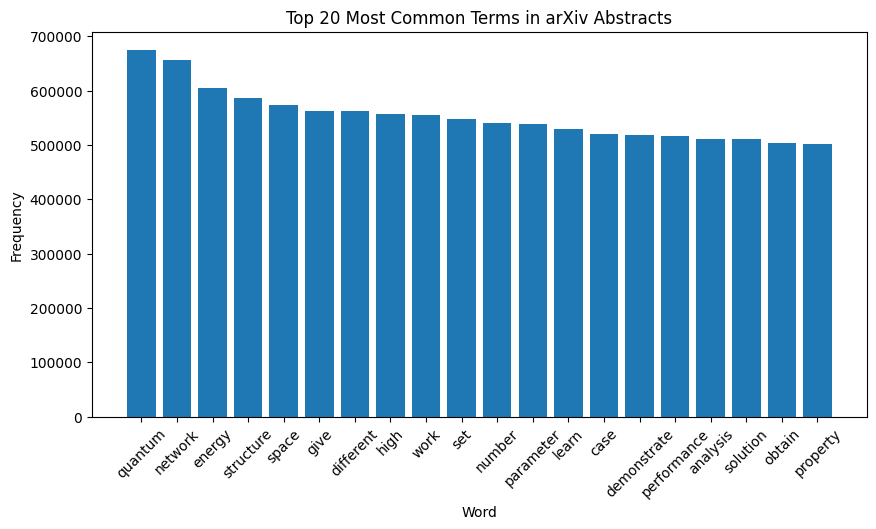

In [11]:
words, counts = zip(*top_20_filtered)

plt.figure(figsize=(10, 5))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Common Terms in arXiv Abstracts")
plt.ylabel("Frequency")
plt.xlabel("Word")
plt.show()

Looking at the graph we can see a steady decrease in the words that are most common. Due to the size of the dataset it is unlikley we will see any significant drops.

The next question we would like to answer is:
* How does vocabulary differ across domains?

Let's first combine our abstracts data with the categories column from the original DataFrame. Since the first category is considered the main category, we will just use that one.

In [12]:
df_eda = df.copy()

df_eda['primary_category'] = df_eda['categories'].str.split().str[0] # Take the first category
df_eda = df_eda.merge(df_abst[['id', 'abstract_clean']], on='id', how='inner')
df_eda = df_eda[['id', 'abstract_clean', 'primary_category']]

In [13]:
# Grouping by category
category_docs = (df_eda.groupby('primary_category')['abstract_clean'].apply(lambda x: " ".join(x)))

In [14]:
# Creating our Term Frequecy/Inverse Document Vectorizer
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

tfidf_matrix = vectorizer.fit_transform(category_docs)

feature_names = vectorizer.get_feature_names_out()

In order to get the top terms for each category we can create a function that creates a dictionary where the category is the key and the top n-terms are the items.

In [15]:
def get_top_terms_per_category(tfidf_matrix, feature_names, category_docs, top_n=10):
    results = {}

    for i, category in enumerate(category_docs.index):
        row = tfidf_matrix[i].toarray().flatten()
        top_indices = row.argsort()[-top_n:][::-1]
        top_terms = [feature_names[idx] for idx in top_indices]

        results[category] = top_terms

    return results

top_terms = get_top_terms_per_category(tfidf_matrix, feature_names, category_docs)

In [16]:
for category, terms in list(top_terms.items())[:5]:
    print(f"\n{category}:")
    print(", ".join(terms))


acc-phys:
beam, muon, collider, accelerator, electron, tev, impedance, proton, cavity, luminosity

adap-org:
extinction, fitness, mutation, market, automaton, traffic, power law, car, boolean, neuron

alg-geom:
projective, cohomology, moduli space, modulus space, sheaf, genus, moduli, divisor, calabiyau, vector bundle

ao-sci:
vapor, atmosphere, convective, power spectrum, ocean, micron, convection, viscous, atmospheric, turbulent

astro-ph:
galaxy, xray, redshift, luminosity, stellar, galactic, star formation, accretion, radio, ngc


This looks a lot more promising, However, let's take a look at how many different categories we have.

In [17]:
len(top_terms)

172

Due to the sheer amount of categories it will be hard to parse through them all. Let's create a function so we can quickly plot categories we are interested in.

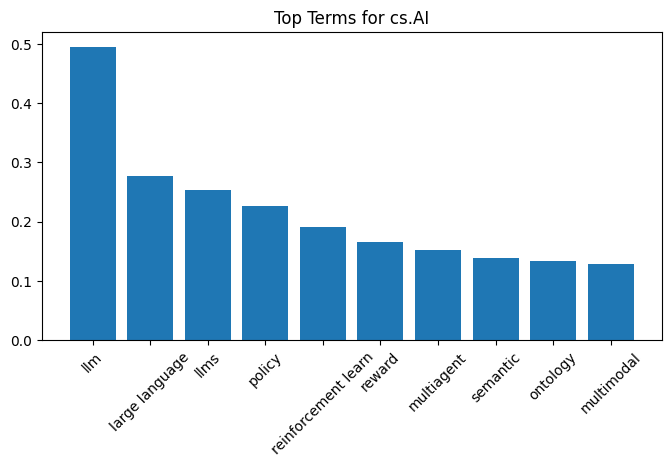

In [18]:
def plot_top_terms(category, tfidf_matrix, feature_names, category_docs, top_n=10):
    idx = list(category_docs.index).index(category)
    row = tfidf_matrix[idx].toarray().flatten()

    top_indices = row.argsort()[-top_n:][::-1]
    terms = [feature_names[i] for i in top_indices]
    scores = [row[i] for i in top_indices]

    plt.figure(figsize=(8, 4))
    plt.bar(terms, scores)
    plt.xticks(rotation=45)
    plt.title(f"Top Terms for {category}")
    plt.show()

# Let's take a look at the cs.AI
plot_top_terms("cs.AI", tfidf_matrix, feature_names, category_docs)

What about something a little bit more physics based.

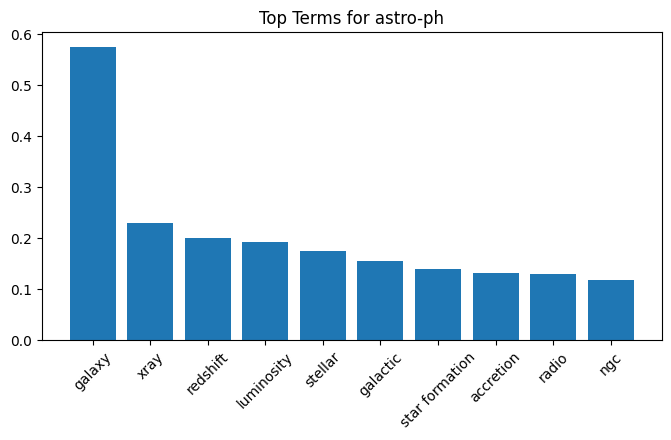

In [19]:
plot_top_terms("astro-ph", tfidf_matrix, feature_names, category_docs)

This seems to be a better approach as the categories really do differentiate which words we would see in papers.

### EDA Takeaways
**Scientific language is highly standardized across domains**

The most common terms across all abstracts are largely domain-agnostic, consisting of words such as “system,” “function,” “data,” and “algorithm”.

This suggests that scientific writing follows a consistent linguistic structure and many high-frequency terms reflect general research processes, rather than domain-specific concepts.

**Domain-specific vocabulary clearly differentiates fields**

Despite shared general language, TF-IDF analysis shows that each domain exhibits a distinct vocabulary signature.

For example:

* cs.AI emphasizes terms like “llm,” “policy,” and “multia”
* astro-ph highlights “galaxy,” “redshift,” and “xray”

This indicates that abstract text alone contains enough signal to distinguish research areas and different disciplines communicate using specialized terminology layered on top of common structure.

## Unsupervised Learning
To investigate whether research papers naturally group into meaningful categories based on their content, we will use unsupervised learning techniques applied to the processed abstract text. Specifically, abstracts are transformed into numerical representations using TF-IDF vectorization, capturing the importance of terms within each document relative to the overall corpus.

Using these representations, we will use KMeans clustering applied to group similar papers without using predefined labels. We will evaluate multiple values of k (number of clusters) using metrics such as inertia and silhouette score to identify an appropriate number of clusters. This allowed for a data-driven selection of cluster structure.

To better understand the results, clusters will be visualized using dimensionality reduction techniques (e.g., PCA) and plots.

The question we want to answer:

* Do similar papers cluster together naturally?

In [20]:
df_model = df_eda.copy()

In [21]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.8
)

X = vectorizer.fit_transform(df_model['abstract_clean'])

Due to the size of the data, we are going to use MiniBatchKMeans to speed it up. We lose out on a bit of precision but gain a lot of speed.

In [22]:
k = 10
# Faster clustering
kmeans = MiniBatchKMeans(
    n_clusters=k,
    random_state=42,
    batch_size=1000,
    n_init=10
)

clusters = kmeans.fit_predict(X)
df_model['cluster'] = clusters

In [23]:
score = silhouette_score(X, clusters, sample_size=5000, random_state=42)
print("Silhouette Score:", score)

Silhouette Score: 0.010027781616247896


The low silhouette score indicates that abstract-based clustering does not produce strongly separated groups. This suggests that research domains exhibit significant semantic overlap and that traditional bag-of-words representations (TF-IDF) may not fully capture deeper relationships between documents. While this is not the outcome we would of hoped for I wouldn't call it a failure. Let's plot of results using PCA to see if we can visually inspect the clusters.

Again, due to the size of the data we will only PCA and plot a sample of it

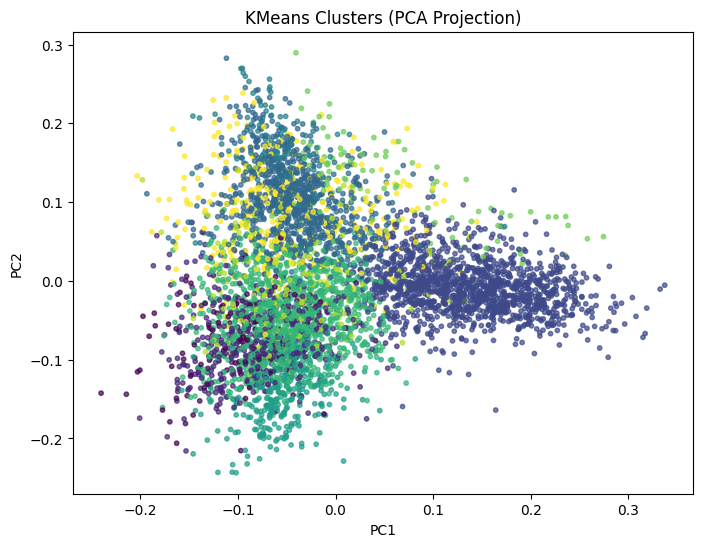

In [24]:
# sample rows for plotting
n_plot = 5000
rng = np.random.default_rng(42)
idx = rng.choice(X.shape[0], size=min(n_plot, X.shape[0]), replace=False)

X_sample = X[idx].toarray()
clusters_sample = df_model['cluster'].iloc[idx]

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_sample, s=10, alpha=0.7)
plt.title("KMeans Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

Even though our Silhouete Score is low, we do see some natural clusters forming. Let's take a look at the top terms per cluster. We will create another function similar to our one from our categories exploration.

In [25]:
terms = vectorizer.get_feature_names_out()

def top_terms_per_cluster(kmeans, terms, n_terms=10):
    for i, center in enumerate(kmeans.cluster_centers_):
        top_indices = center.argsort()[-n_terms:][::-1]
        top_words = [terms[idx] for idx in top_indices]
        print(f"\nCluster {i}:")
        print(", ".join(top_words))

top_terms_per_cluster(kmeans, terms)


Cluster 0:
phase, transition, phase transition, temperature, state, order, system, critical, phase diagram, lattice

Cluster 1:
magnetic, field, state, spin, temperature, magnetic field, electron, effect, material, surface

Cluster 2:
data, network, propose, learn, performance, image, task, system, algorithm, framework

Cluster 3:
space, function, prove, give, theory, algebra, operator, set, bound, number

Cluster 4:
group, subgroup, finite, algebra, prove, representation, let, action, lie, space

Cluster 5:
star, galaxy, mass, cluster, emission, stellar, xray, observation, disk, line

Cluster 6:
energy, mass, particle, decay, study, parameter, data, effect, find, present

Cluster 7:
graph, vertex, edge, number, problem, set, algorithm, graphs, node, bound

Cluster 8:
quantum, state, system, entanglement, classical, theory, measurement, circuit, quantum state, quantum system

Cluster 9:
equation, solution, problem, system, nonlinear, condition, function, numerical, solve, differential

Again, though our Silhouete Score is low, there clearly seems to be different terms in different clusters. Let's go ahead and try to see if we can find a good number of clusters.

In [26]:
k_values = [5, 10, 15, 20]
results = []

rng = np.random.default_rng(42)
n_eval = min(5000, X.shape[0])
eval_idx = rng.choice(X.shape[0], size=n_eval, replace=False)

X_eval_sparse = X[eval_idx]
X_eval_dense = X_eval_sparse.toarray()

for k in k_values:
    print(f"Fitting KMeans for k={k}...")

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=1000,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    inertia = kmeans.inertia_

    # Only evaluate expensive metrics on sample
    eval_labels = labels[eval_idx]

    silhouette = silhouette_score(
        X_eval_sparse,
        eval_labels,
        random_state=42
    )

    db_score = davies_bouldin_score(X_eval_dense, eval_labels)
    ch_score = calinski_harabasz_score(X_eval_dense, eval_labels)

    results.append({
        "k": k,
        "inertia": inertia,
        "silhouette_score": silhouette,
        "davies_bouldin_score": db_score,
        "calinski_harabasz_score": ch_score
    })

results_df = pd.DataFrame(results)
results_df

Fitting KMeans for k=5...
Fitting KMeans for k=10...
Fitting KMeans for k=15...
Fitting KMeans for k=20...


,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,5,2.861658e+06,0.006864,10.333620,24.814480
1,10,2.821880e+06,0.009191,7.998303,19.255276
2,15,2.796825e+06,0.009753,8.264149,16.018079
3,20,2.771973e+06,0.010970,7.126113,14.580142


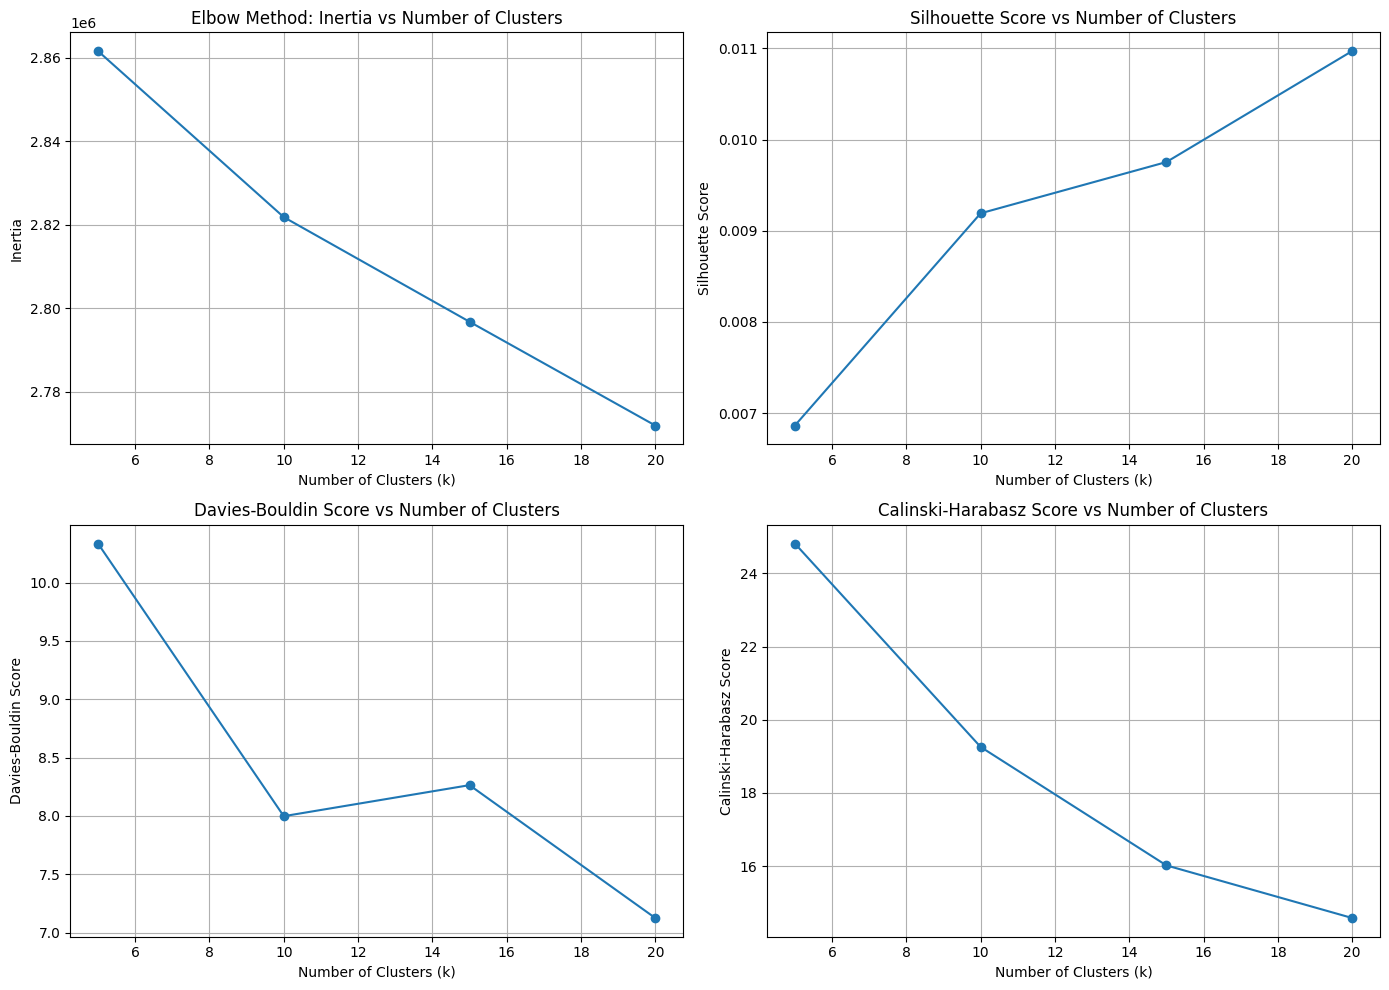

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Elbow plot: Inertia
axes[0, 0].plot(results_df['k'], results_df['inertia'], marker='o')
axes[0, 0].set_title('Elbow Method: Inertia vs Number of Clusters')
axes[0, 0].set_xlabel('Number of Clusters (k)')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].grid(True)

# Silhouette score
axes[0, 1].plot(results_df['k'], results_df['silhouette_score'], marker='o')
axes[0, 1].set_title('Silhouette Score vs Number of Clusters')
axes[0, 1].set_xlabel('Number of Clusters (k)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].grid(True)

# Davies-Bouldin score (lower is better)
axes[1, 0].plot(results_df['k'], results_df['davies_bouldin_score'], marker='o')
axes[1, 0].set_title('Davies-Bouldin Score vs Number of Clusters')
axes[1, 0].set_xlabel('Number of Clusters (k)')
axes[1, 0].set_ylabel('Davies-Bouldin Score')
axes[1, 0].grid(True)

# Calinski-Harabasz score (higher is better)
axes[1, 1].plot(results_df['k'], results_df['calinski_harabasz_score'], marker='o')
axes[1, 1].set_title('Calinski-Harabasz Score vs Number of Clusters')
axes[1, 1].set_xlabel('Number of Clusters (k)')
axes[1, 1].set_ylabel('Calinski-Harabasz Score')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### Unsupervised Results
To determine an appropriate number of clusters, KMeans was evaluated across multiple values of k using several metrics: inertia, silhouette score, Davies-Bouldin score, and Calinski-Harabasz score.

#### Observations
Inertia decreases steadily as k increases, which is expected, but no clear “elbow” point is observed. This suggests the absence of a natural number of clusters in the data.
Silhouette scores are consistently low, indicating weak separation between clusters regardless of the number of clusters chosen.
Davies-Bouldin scores improve (decrease) as k increases, suggesting that clusters become more compact and locally distinct.
Calinski-Harabasz scores decrease with increasing k, indicating that larger numbers of clusters may lead to more fragmented and less globally cohesive groupings.
#### Interpretation

These results suggest that the dataset does not exhibit strong, well-separated cluster structure when represented using TF-IDF features. While increasing the number of clusters improves local cohesion, overall separation between clusters remains weak.

This behavior likely reflects:

* Significant vocabulary overlap across research domains
* The inherently interdisciplinary nature of scientific research
* Limitations of bag-of-words representations in capturing deeper semantic relationships

#### Conclusion

Although no single value of k emerges as clearly optimal, values in the range of 15–20 clusters provide a reasonable balance between cluster compactness and interpretability. These configurations are used in subsequent analysis to explore the semantic structure of the dataset.

#### Addtional Thoughts

Despite the weak quantitative metrics, qualitative analysis of the clusters reveals a different and more compelling picture. By examining the top terms associated with each cluster, clear and interpretable themes emerge, corresponding to well-defined research domains such as quantum physics, astrophysics, machine learning, combinatorics and more.

This contrast highlights an important insight:

* Traditional clustering metrics evaluate geometric separation in feature space
* However, in high-dimensional text data, meaningful structure may exist even when clusters are not well-separated geometrically

In this case, the clusters are semantically coherent, they capture distinct topics, despite overlapping in the TF-IDF feature space. This suggests that while the clustering model does not produce strongly separated groups according to standard metrics, it is still effective at uncovering latent thematic structure in the data.